In [28]:
!unzip -q /content/*.zip -d /content/dms_raw
print("Extraction complete!")

caution: filename not matched:  /content/Sohini_Processed_Dataset.zip
Extraction complete!


In [29]:
import os
import glob
import yaml
import shutil
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Starting Processing Pipeline ---")

# 1. SETUP FINAL FOLDERS
output_base = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

# Cleaning up any old runs
if os.path.exists(output_base):
    shutil.rmtree(output_base)

for split in splits:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)

# 2. FILTER & REMAP CLASSES
# Kaggle Original: 3 = Phone, 4 = Seatbelt -> map them to 0 and 1.
CLASS_MAP = {'3': '0', '4': '1'}
stats = {'Phone': 0, 'Seatbelt': 0, 'Total_Images': 0}

for split in splits:
    raw_img_dir = os.path.join('/content/dms_raw', split, 'images')
    raw_lbl_dir = os.path.join('/content/dms_raw', split, 'labels')

    # Handle naming variations (sometimes 'valid' is called 'val')
    if not os.path.exists(raw_img_dir) and split == 'valid':
        raw_img_dir = os.path.join('/content/dms_raw', 'val', 'images')
        raw_lbl_dir = os.path.join('/content/dms_raw', 'val', 'labels')

    if not os.path.exists(raw_img_dir):
        continue

    # Find all images
    image_paths = glob.glob(os.path.join(raw_img_dir, '*.jpg')) + \
                  glob.glob(os.path.join(raw_img_dir, '*.png'))

    for img_path in image_paths:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(raw_lbl_dir, f"{base_name}.txt")

        if not os.path.exists(txt_path):
            continue

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        valid_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            class_id = parts[0]
            if class_id in CLASS_MAP:
                # Basic quality check: ensure coordinates are valid YOLO format (0 to 1)
                coords = [float(x) for x in parts[1:]]
                if any(c < 0.0 or c > 1.0 for c in coords):
                    continue

                parts[0] = CLASS_MAP[class_id]
                valid_lines.append(" ".join(parts) + "\n")

                if parts[0] == '0': stats['Phone'] += 1
                if parts[0] == '1': stats['Seatbelt'] += 1

        # If we kept at least one valid box, copy the image and new label over
        if valid_lines:
            stats['Total_Images'] += 1
            shutil.copy(img_path, os.path.join(output_base, split, 'images', os.path.basename(img_path)))

            with open(os.path.join(output_base, split, 'labels', f"{base_name}.txt"), 'w') as f:
                f.writelines(valid_lines)

print(f"\n--- Metrics ---")
print(f"Total Filtered Images Saved: {stats['Total_Images']}")
print(f"Total Phone Boxes: {stats['Phone']}")
print(f"Total Seatbelt Boxes: {stats['Seatbelt']}")

# 3. CREATE DATA.YAML
yaml_data = {
    'train': '../train/images',
    'val': '../valid/images',
    'test': '../test/images',
    'nc': 2,
    'names': ['Phone', 'Seatbelt']
}

with open(os.path.join(output_base, 'data.yaml'), 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

# 4. ZIPPING FINAL FOLDER FOR DOWNLOAD
archive_path = '/content/Sohini_Processed_Dataset'
shutil.make_archive(archive_path, 'zip', output_base)

print(f"\n--- SUCCESS! ---")
print(f"Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.")

--- Starting Processing Pipeline ---

--- Metrics ---
Total Filtered Images Saved: 6140
Total Phone Boxes: 2552
Total Seatbelt Boxes: 4149

--- SUCCESS! ---
Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.


In [32]:
import os
import glob

dataset_dir = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

print("==================================================")
print(" 1. CLASS MAPPING & DOCUMENTATION")
print("==================================================")
print("Target classes tracked explicitly via YOLO bounding boxes:")
print(" - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)")
print(" - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)")
print("\nNegative states handled implicitly (Absence of bounding box):")
print(" - 'no seat belt' / 'person without seat belt'")
print(" - 'no phone usage'")
print("==================================================\n")

print("==================================================")
print(" 2. DATASET SIZE & METRICS CHECK")
print("==================================================")

total_images = 0
total_labels = 0
class_counts = {'0 (Phone)': 0, '1 (Seatbelt)': 0}

for split in splits:
    img_dir = os.path.join(dataset_dir, split, 'images')
    lbl_dir = os.path.join(dataset_dir, split, 'labels')

    # Handle 'val' naming variation
    if not os.path.exists(img_dir) and split == 'valid':
        img_dir = os.path.join(dataset_dir, 'val', 'images')
        lbl_dir = os.path.join(dataset_dir, 'val', 'labels')

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Skipping {split} - Directory not found.")
        continue

    # Count Images
    images = glob.glob(os.path.join(img_dir, '*.jpg')) + glob.glob(os.path.join(img_dir, '*.png'))
    split_img_count = len(images)
    total_images += split_img_count

    # Count Labels
    labels = glob.glob(os.path.join(lbl_dir, '*.txt'))
    split_lbl_count = len(labels)
    total_labels += split_lbl_count

    # Count Bounding Boxes
    for txt_file in labels:
        with open(txt_file, 'r') as f:
            for line in f:
                class_id = line.strip().split()[0]
                if class_id == '0':
                    class_counts['0 (Phone)'] += 1
                elif class_id == '1':
                    class_counts['1 (Seatbelt)'] += 1

    print(f"[{split.upper()} SPLIT]")
    print(f"  - Images: {split_img_count}")
    print(f"  - Label Files: {split_lbl_count}")

print("\n[TOTAL DATASET METRICS]")
print(f"  - Total Images: {total_images}")
print(f"  - Total Label Files: {total_labels}")
print(f"  - Total 'Phone' Bounding Boxes: {class_counts['0 (Phone)']}")
print(f"  - Total 'Seatbelt' Bounding Boxes: {class_counts['1 (Seatbelt)']}")
print("==================================================")

 1. CLASS MAPPING & DOCUMENTATION
Target classes tracked explicitly via YOLO bounding boxes:
 - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)
 - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)

Negative states handled implicitly (Absence of bounding box):
 - 'no seat belt' / 'person without seat belt'
 - 'no phone usage'

 2. DATASET SIZE & METRICS CHECK
[TRAIN SPLIT]
  - Images: 3534
  - Label Files: 3534
[VALID SPLIT]
  - Images: 1959
  - Label Files: 1959
[TEST SPLIT]
  - Images: 647
  - Label Files: 647

[TOTAL DATASET METRICS]
  - Total Images: 6140
  - Total Label Files: 6140
  - Total 'Phone' Bounding Boxes: 2552
  - Total 'Seatbelt' Bounding Boxes: 4149


--- Generating Fundamental Object Detection EDA ---


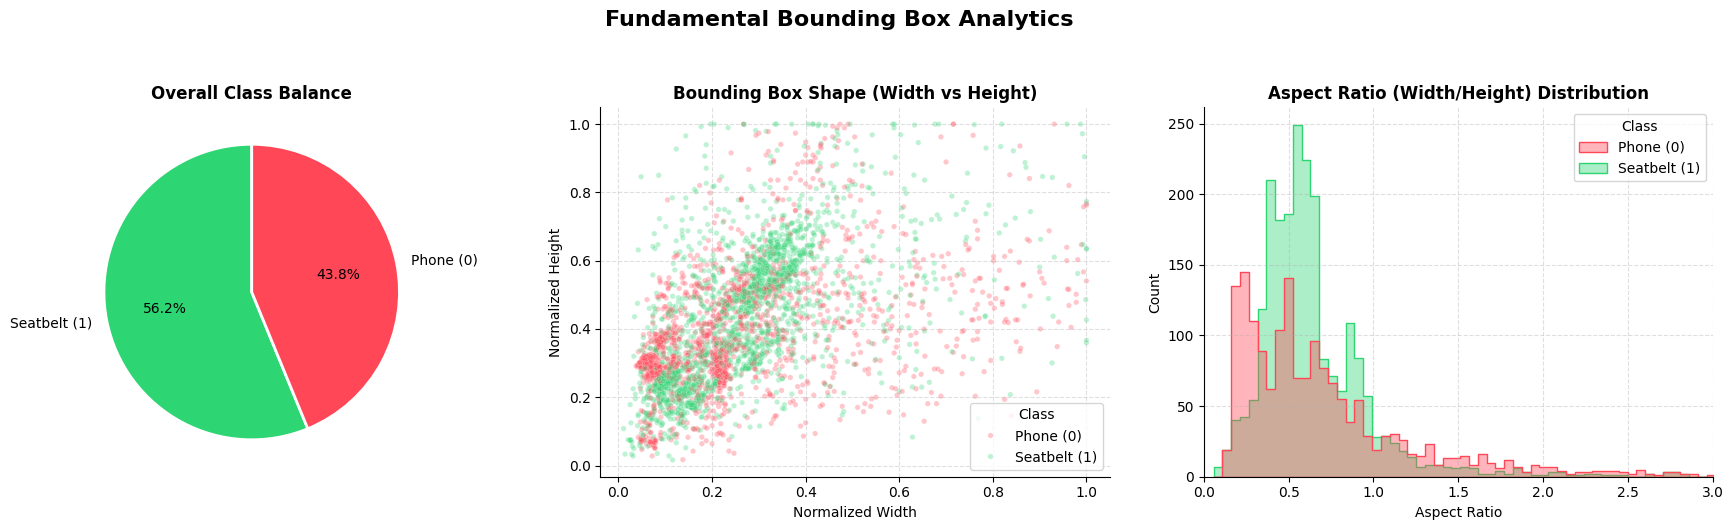

Saved: /content/basic_yolo_eda.png


In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths based on your processed dataset
train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Fundamental Object Detection EDA ---")

# 1. Gather the basic dimensional data
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'
                aspect_ratio = w / h if h > 0 else 0

                data.append({
                    'Class': class_name,
                    'Width': w,
                    'Height': h,
                    'Aspect_Ratio': aspect_ratio
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Fundamental Bounding Box Analytics', fontsize=16, fontweight='bold', y=1.05)

    # ==========================================================
    # Plot 1: Overall Class Balance (Pie Chart)
    # ==========================================================
    class_counts = df['Class'].value_counts()
    axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
                colors=['#2ed573', '#ff4757'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Overall Class Balance', fontweight='bold')

    # ==========================================================
    # Plot 2: Width vs Height Scatter (Shape Analysis)
    # ==========================================================
    sns.scatterplot(data=df, x='Width', y='Height', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.3, s=15, ax=axes[1])
    axes[1].set_title('Bounding Box Shape (Width vs Height)', fontweight='bold')
    axes[1].set_xlabel('Normalized Width')
    axes[1].set_ylabel('Normalized Height')
    axes[1].grid(linestyle='--', alpha=0.4)

    # ==========================================================
    # Plot 3: Aspect Ratio Distribution
    # ==========================================================
    sns.histplot(data=df, x='Aspect_Ratio', hue='Class', element="step",
                 palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                 ax=axes[2], common_norm=False, alpha=0.4)
    axes[2].set_title('Aspect Ratio (Width/Height) Distribution', fontweight='bold')
    axes[2].set_xlabel('Aspect Ratio')
    axes[2].set_ylabel('Count')
    axes[2].set_xlim(0, 3) # Cap X axis to keep it readable, as most ratios fall between 0 and 2
    axes[2].grid(linestyle='--', alpha=0.4)

    sns.despine(ax=axes[1])
    sns.despine(ax=axes[2])
    plt.tight_layout()

    basic_chart_path = '/content/basic_yolo_eda.png'
    plt.savefig(basic_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {basic_chart_path}")
else:
    print("No bounding box data found to plot.")

--- Generating Advanced Spatial EDA ---


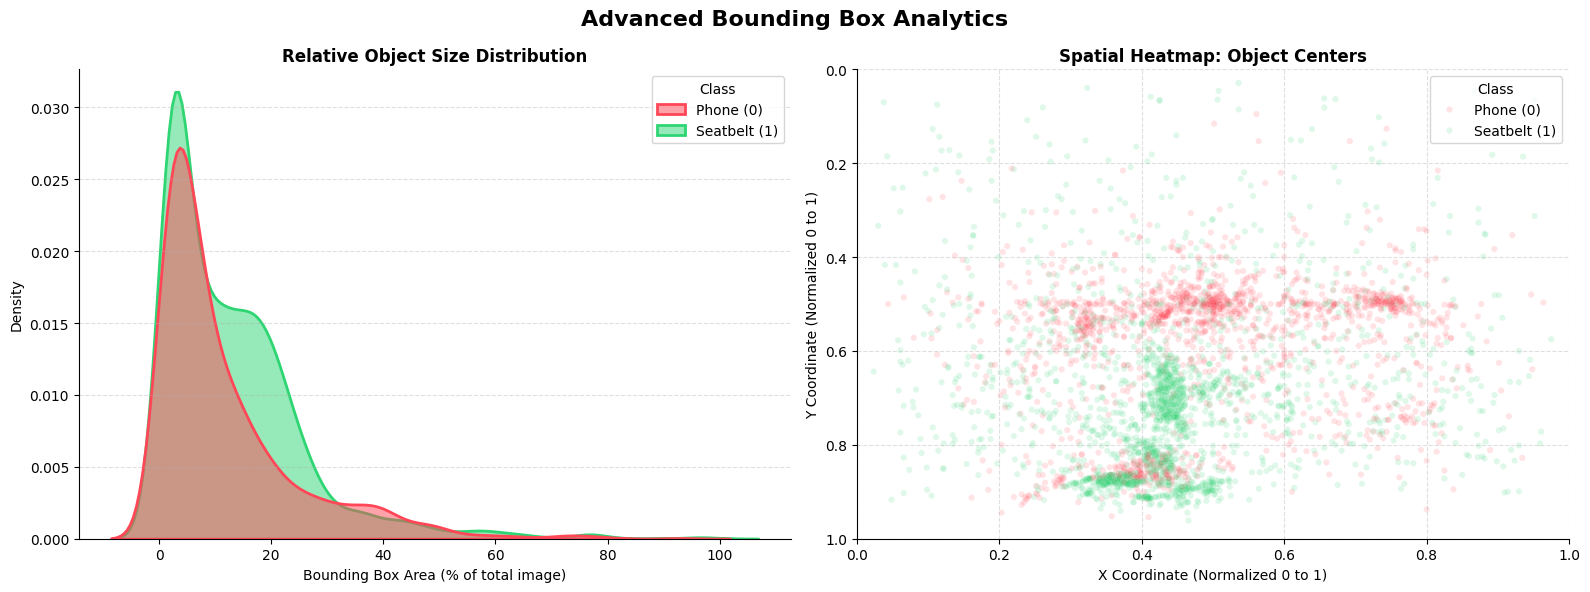

Saved: /content/advanced_spatial_eda.png


In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Advanced Spatial EDA ---")

# 1. Parse all labels into a DataFrame
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                # YOLO format gives normalized width and height. Area = w * h
                area = (w * h) * 100 # Convert to percentage of total image area
                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'

                data.append({
                    'Class': class_name,
                    'X_Center': x,
                    'Y_Center': y, # In images, Y=0 is the top, Y=1 is the bottom
                    'Area_Percent': area
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Advanced Bounding Box Analytics', fontsize=16, fontweight='bold')

    # ==========================================================
    # Plot 1: Object Size (Area) Distribution
    # ==========================================================
    sns.kdeplot(data=df, x='Area_Percent', hue='Class', fill=True,
                palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                ax=axes[0], alpha=0.5, linewidth=2)

    axes[0].set_title('Relative Object Size Distribution', fontweight='bold')
    axes[0].set_xlabel('Bounding Box Area (% of total image)')
    axes[0].set_ylabel('Density')
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # ==========================================================
    # Plot 2: Spatial Distribution (Where do objects appear?)
    # ==========================================================
    sns.scatterplot(data=df, x='X_Center', y='Y_Center', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.15, s=20, ax=axes[1])

    axes[1].set_title('Spatial Heatmap: Object Centers', fontweight='bold')
    axes[1].set_xlabel('X Coordinate (Normalized 0 to 1)')
    axes[1].set_ylabel('Y Coordinate (Normalized 0 to 1)')

    # Invert Y-axis so the plot matches how images are rendered (0,0 at top left)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(1, 0)
    axes[1].grid(linestyle='--', alpha=0.4)

    sns.despine()
    plt.tight_layout()

    adv_chart_path = '/content/advanced_spatial_eda.png'
    plt.savefig(adv_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {adv_chart_path}")
else:
    print("No bounding box data found to plot.")

--- Generating EDA Visualizations ---


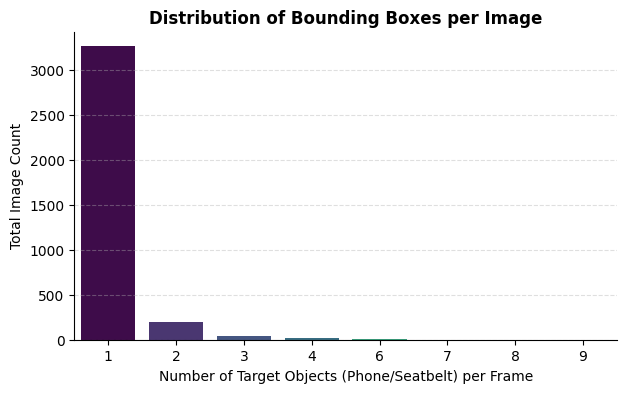

Saved: /content/boxes_per_image_chart.png



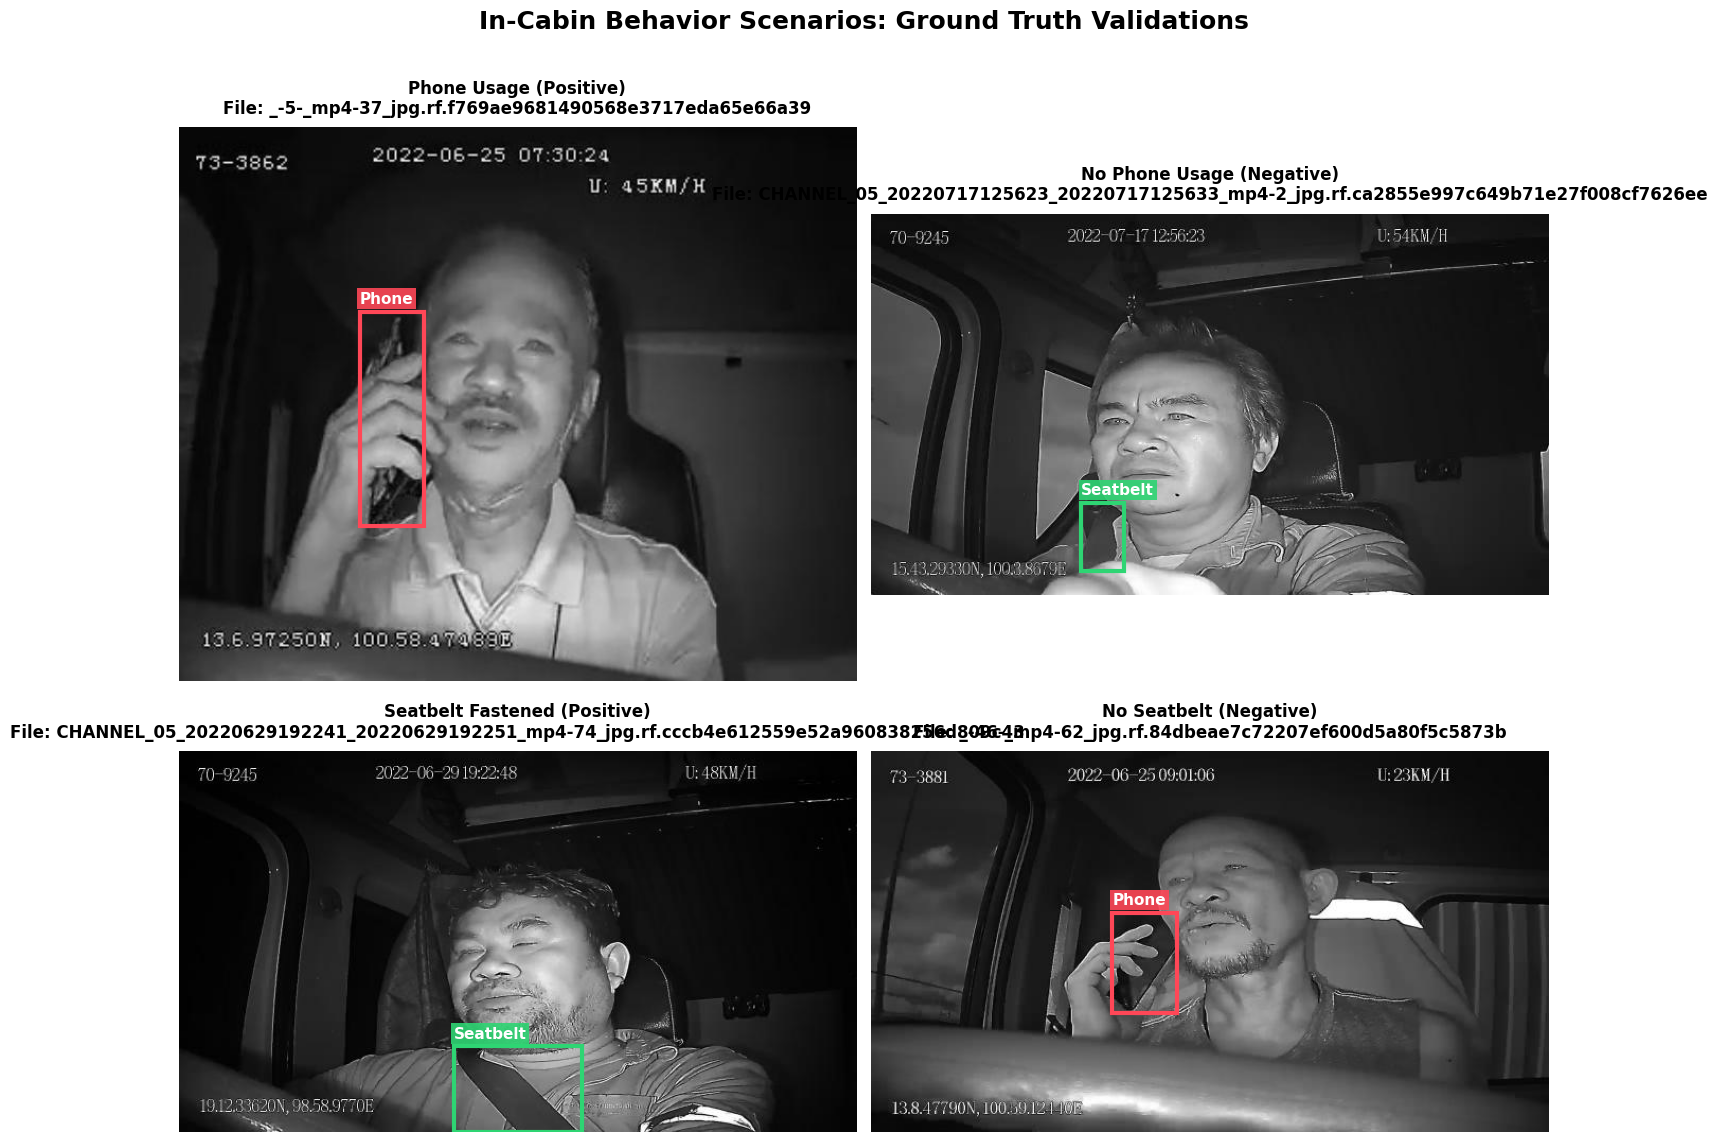

Saved: /content/scenario_grid_annotated.png

--- DONE! Your polished graphics are ready for the presentation. ---


In [36]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

# =====================================================================
# CONFIGURATION & PATHS
# =====================================================================
train_images_dir = '/content/dms_processed_yolo/train/images'
train_labels_dir = '/content/dms_processed_yolo/train/labels'

# Class UI Mapping for clean rendering
CLASS_UI = {
    0: {'label': 'Phone', 'color': '#ff4757'},    # Vibrant Red
    1: {'label': 'Seatbelt', 'color': '#2ed573'}  # Vibrant Green
}

print("--- Generating EDA Visualizations ---")

# =====================================================================
# HELPER FUNCTION: ROBUST IMAGE FINDER
# =====================================================================
def get_image_path(base_name, img_dir):
    """Safely finds the image file regardless of its extension."""
    valid_extensions = ['.jpg', '.JPG', '.png', '.PNG', '.jpeg', '.JPEG']
    for ext in valid_extensions:
        path = os.path.join(img_dir, base_name + ext)
        if os.path.exists(path):
            return path
    return None

# =====================================================================
# 1. BOXES PER IMAGE DISTRIBUTION CHART
# =====================================================================
boxes_per_image = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        # Count non-empty lines
        lines = [line for line in f.readlines() if line.strip()]
        boxes_per_image.append(len(lines))

plt.figure(figsize=(7, 4))
sns.countplot(x=boxes_per_image, hue=boxes_per_image, palette="viridis", legend=False)
plt.title('Distribution of Bounding Boxes per Image', fontweight='bold')
plt.xlabel('Number of Target Objects (Phone/Seatbelt) per Frame')
plt.ylabel('Total Image Count')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right spines for a cleaner, modern look
sns.despine()

chart2_path = '/content/boxes_per_image_chart.png'
plt.savefig(chart2_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {chart2_path}\n")

# =====================================================================
# 2. SCENARIO FILTERING & 2x2 ANNOTATION GRID
# =====================================================================
phone_pos, phone_neg = [], []
seatbelt_pos, seatbelt_neg = [], []

# Categorize files based on class presence
for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        classes = {line.strip().split()[0] for line in f.readlines() if line.strip()}

    if '0' in classes: phone_pos.append(txt_file)
    else: phone_neg.append(txt_file)

    if '1' in classes: seatbelt_pos.append(txt_file)
    else: seatbelt_neg.append(txt_file)

# Map scenarios to a random sample
scenarios = {
    "Phone Usage (Positive)": random.choice(phone_pos) if phone_pos else None,
    "No Phone Usage (Negative)": random.choice(phone_neg) if phone_neg else None,
    "Seatbelt Fastened (Positive)": random.choice(seatbelt_pos) if seatbelt_pos else None,
    "No Seatbelt (Negative)": random.choice(seatbelt_neg) if seatbelt_neg else None
}

# Setup 2x2 Grid Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('In-Cabin Behavior Scenarios: Ground Truth Validations', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for idx, (title, txt_filename) in enumerate(scenarios.items()):
    ax = axes[idx]
    if txt_filename is None:
        ax.text(0.5, 0.5, "Scenario Not Found", ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
        continue

    base_name = txt_filename.replace('.txt', '')
    img_path = get_image_path(base_name, train_images_dir)

    if img_path:
        img = Image.open(img_path)
        img_width, img_height = img.size
        ax.imshow(img)

        # Read labels and draw bounding boxes
        with open(os.path.join(train_labels_dir, txt_filename), 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if not parts: continue

                class_id = int(parts[0])
                x_center, y_center, w, h = map(float, parts[1:])

                # YOLO to Pixel Math
                box_w = w * img_width
                box_h = h * img_height
                box_x = (x_center * img_width) - (box_w / 2)
                box_y = (y_center * img_height) - (box_h / 2)

                ui = CLASS_UI.get(class_id, {'label': 'Unknown', 'color': 'yellow'})

                # Draw Rectangle
                rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=3, edgecolor=ui['color'], facecolor='none')
                ax.add_patch(rect)

                # Draw sleek text tag
                ax.text(box_x, max(box_y - 8, 0), ui['label'],
                        color='white', fontsize=11, fontweight='bold',
                        bbox=dict(facecolor=ui['color'], edgecolor='none', pad=2.0, alpha=0.9))

        ax.set_title(f"{title}\nFile: {base_name}", fontweight='bold', pad=10)
    else:
        ax.set_title(f"Image Missing for {txt_filename}")

    ax.axis('off')

plt.tight_layout()
grid_path = '/content/scenario_grid_annotated.png'
plt.savefig(grid_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Saved: {grid_path}")
print("\n--- DONE! Your polished graphics are ready for the presentation. ---")